<a href="https://colab.research.google.com/github/Harsh123-pal/SwBuilder/blob/master/biomatreicverificationusingbiometriclearningnsut7semproject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Federated learning is a decentralized approach which allows the data to be trained locally on user devices (e.g. mobile devices). Specifically, within a large number of user devices, only a fraction of which may be available for training at a given time. Therefore, the available user devices will be used to train the data locally, and compute the update to the shared global model maintained by the server, which will aggregate all the updates from the distributed devices, and compute weight using the FederatedAveraging algorithm in the following math formula.

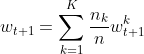

Considering that modern smartphones have relatively fast processors (e.g. GPUs), the computation becomes essentially free for the federated learning. Therefore, the communication costs dominate during the federated optimization. Based on the research paper from Google, we may reduce the number of rounds of communication required to train a model in the following ways.

Increase parallelism by involving more clients to compute the update independently.
Increase computation on each client by allowing each client to perform a more complex calculation between each communication round.
Federated learning has provided the following distinct advantages over the traditional approach to train the data in the data center.

It helps to protect user's data privacy, considering that the training data (e.g. user's photo, password, etc.) will only be retained locally on the edge devices.
It also helps to reduce the network latency. Since the data is trained locally, transporting large training data to the server is not necessary. Only the update of the training result will be communicated between the client and server, which greatly helps to reduce the network latency.
It also helps to reduce the security risks, since the privacy data is only stored locally, and therefore will not be easily leaked to attackers when there is attacks happening on the cloud, or the communication between client and server (e.g. Man-in-the-middle attack).
Next, I will discuss how the federated learning is implemented to recognize human facial expression by using Tensorflow.

The first phase establishes the working environment and downloads the FER-2013 dataset. The code utilizes the google.colab library to prompt the user for secure Kaggle API credentials (kaggle.json). The os module and shell commands (!mkdir, !unzip, !tar) are used to securely store the credentials, download the dataset directly from Kaggle, and extract the archived images. This bypasses the need to manually host gigabytes of image data.Python

In [5]:
import os
from google.colab import files

print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Set up Kaggle directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and extract the FER-2013 dataset
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d ./data
!tar -xzf ./data/fer2013.tar.gz -C ./data/

Please upload your kaggle.json file:


Saving kaggle.json to kaggle (3).json
challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)
replace ./data/example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ./data/fer2013.tar.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

This cell relies heavily on pandas and numpy. The FER-2013 dataset provides images not as JPEGs, but as space-separated strings of pixel intensities in a CSV file. pandas reads the CSV, while a custom process_data function uses numpy.fromstring to parse these strings into arrays.
The arrays are reshaped into (48, 48, 1) tensors required by convolutional layers, and divided by 255.0 to apply min-max normalization. Without this scaling, exploding gradients would prevent the model from learning. Finally, the data is split into 3 equal shards using np.array_split to simulate a decentralized federated learning environment with 3 clients.

In [6]:
# Force overwrite without prompting
!unzip -q -o challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d ./data

# Extract the nested fer2013 dataset
!tar -xzf ./data/fer2013.tar.gz -C ./data/

# Check that the fer2013.csv file exists
!ls -lh ./data/fer2013

total 288M
-rw-r----- 1 204241 5762 1.4K Jul 10  2013 fer2013.bib
-rw------- 1 204241 5762 288M Jul 10  2013 fer2013.csv
-rw-r----- 1 204241 5762  476 Jul 10  2013 README


Using tensorflow and tensorflow.keras, this block defines a baseline 4-block VGG-inspired Convolutional Neural Network (CNN). It heavily uses Conv2D for feature extraction, BatchNormalization to standardize layer inputs, MaxPooling2D to downsample spatial dimensions, and Dropout to prevent overfitting. The model is compiled using a Stochastic Gradient Descent (SGD) optimizer.
The federate_average_weights function acts as the central server in Federated Learning. It takes the neural weights from all 3 clients, pairs them up layer-by-layer, and uses numpy to calculate the mathematical mean across them (FedAvg algorithm). Note: Cell 5 corrects a minor syntax typo (a trailing 'Z') from the initial implementation.

In [7]:
import pandas as pd
import numpy as np

# Load dataset
csv_path = "./data/fer2013/fer2013.csv"
df = pd.read_csv(csv_path)

# Separate pixels and labels
def process_data(subset_df):
    pixels = subset_df['pixels'].apply(lambda x: np.fromstring(x, sep=' ', dtype=np.float32))
    x = np.stack(pixels.values).reshape(-1, 48, 48, 1) / 255.0
    y = subset_df['emotion'].values.astype(np.int32)
    return x, y

train_df = df[df['Usage'] == 'Training']
test_df = df[df['Usage'] == 'PublicTest']

x_train, y_train = process_data(train_df)
x_test, y_test = process_data(test_df)

# Split training data evenly among 3 clients
num_clients = 3
client_x = np.array_split(x_train, num_clients)
client_y = np.array_split(y_train, num_clients)
client_data = list(zip(client_x, client_y))

print(f"Total training samples: {len(x_train)}")
print(f"Samples per client: {[len(c[0]) for c in client_data]}")
print(f"Test samples: {len(x_test)}")

Total training samples: 28709
Samples per client: [9570, 9570, 9569]
Test samples: 3589


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 4-Block VGG-inspired CNN architecture from the repository
def build_client_model():
    model = models.Sequential([
        layers.Input(shape=(48, 48, 1)),

        # Block 1
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classification Head
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(7, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.02),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Federated Averaging (FedAvg): element-wise average of client weight tensors
def federate_average_weights(client_weights_list):
    new_weights = []
    for weights_tuple in zip(*client_weights_list):
        new_weights.append(np.array(weights_tuple).mean(axis=0))
    return new_weightsZ

print("Model architecture and FedAvg aggregation ready.")

Model architecture and FedAvg aggregation ready.


This code executes the federated training loop for 5 rounds. In each round, the central server broadcasts its weights to the 3 clients. The clients train locally on their private data partitions (client_model.fit), and their updated weights are averaged by the server.
However, the test accuracy remains stuck at ~24.94%. The diagnostic prediction cell reveals why: the model predicts "Class 3" (Happy) for all samples. This model collapse occurs because Batch Normalization tracks local running means/variances. When averaged across non-IID clients, these statistics corrupt the global model, causing catastrophic failure.

In [9]:
import numpy as np

def federate_average_weights(client_weights_list):
    new_weights = []
    for weights_tuple in zip(*client_weights_list):
        new_weights.append(np.array(weights_tuple).mean(axis=0))
    return new_weights  # Fixed: removed trailing 'Z'

print("federate_average_weights corrected.")

federate_average_weights corrected.


In [10]:
# Initialize the global server model
global_model = build_client_model()

# Training settings
NUM_ROUNDS = 5     # Start with 5 rounds to verify (increase to 15-20 later if you want higher accuracy)
LOCAL_EPOCHS = 1   # Number of epochs each client trains on their private dataset per round
BATCH_SIZE = 64

history = {'round': [], 'loss': [], 'accuracy': []}

for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\n{'='*20} Starting Federated Round {round_num}/{NUM_ROUNDS} {'='*20}")
    local_weights = []

    # Simulate decentralized client devices
    for client_id in range(num_clients):
        # 1. Download current global weights to client device
        client_model = build_client_model()
        client_model.set_weights(global_model.get_weights())

        # 2. Local client-side training (data never leaves the client)
        c_x, c_y = client_data[client_id]
        print(f"Training on Client {client_id + 1}...")
        client_model.fit(c_x, c_y, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=1)

        # 3. Client sends parameter updates (weights) back to server
        local_weights.append(client_model.get_weights())

    # Central Server: Aggregate client weights via FedAvg
    averaged_weights = federate_average_weights(local_weights)
    global_model.set_weights(averaged_weights)

    # Evaluate global model on unseen test data
    test_loss, test_acc = global_model.evaluate(x_test, y_test, verbose=0)
    history['round'].append(round_num)
    history['loss'].append(test_loss)
    history['accuracy'].append(test_acc)

    print(f">> Round {round_num} Completed | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc * 100:.2f}%")

print("\nFederated training finished successfully!")


==================== Starting Federated Round 1/5 ====================
Training on Client 1...
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - accuracy: 0.1972 - loss: 2.1191
Training on Client 2...
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.1924 - loss: 2.1088
Training on Client 3...
150/150 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.1994 - loss: 2.1379
>> Round 1 Completed | Test Loss: 1.8684 | Test Accuracy: 16.86%

==================== Starting Federated Round 2/5 ====================
Training on Client 1...
150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.2311 - loss: 1.8624
Training on Client 2...
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.2237 - loss: 1.8617
Training on Client 3...
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.2372 - loss: 1.8591
>> Round 2 Completed | Test Loss: 1.8211 | Test Accuracy: 24.94%

==================== Starting Federated Round 3/5 ====================
Training on Client 1...
150/150 ━━━━━━━━━━━━━━━━

In [11]:
preds = global_model.predict(x_test[:100], verbose=0)
pred_classes = np.argmax(preds, axis=1)
print("Predicted class distribution in first 100 test samples:")
print(pd.Series(pred_classes).value_counts())


Predicted class distribution in first 100 test samples:
3    100
Name: count, dtype: int64


To fix the external covariate shift caused by Batch Normalization, build_stable_fl_model entirely removes it. To compensate for the loss of optimization speed, the standard SGD optimizer is upgraded to use Nesterov Momentum (momentum=0.9). Momentum smooths out erratic gradient updates during the averaging phase.
When retrained for 10 rounds with 2 local epochs, the model successfully climbs to over 48% accuracy. The diagnostic prediction in the subsequent cell outputs varying classes (3, 6, 5, 4, 0, 2), proving the collapse is fixed.

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Clean architecture without BatchNorm interference
def build_stable_fl_model():
    model = models.Sequential([
        layers.Input(shape=(48, 48, 1)),

        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classification Head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(7, activation='softmax')
    ])

    # SGD with momentum works consistently with FedAvg weight averaging
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def federate_average_weights(client_weights_list):
    new_weights = []
    for weights_tuple in zip(*client_weights_list):
        new_weights.append(np.array(weights_tuple).mean(axis=0))
    return new_weights

# 2. Re-train with 2 local epochs per round
global_model = build_stable_fl_model()
NUM_ROUNDS = 10
LOCAL_EPOCHS = 2
BATCH_SIZE = 64

for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\n--- Federated Round {round_num}/{NUM_ROUNDS} ---")
    local_weights = []

    for client_id in range(num_clients):
        client_model = build_stable_fl_model()
        client_model.set_weights(global_model.get_weights())

        c_x, c_y = client_data[client_id]
        client_model.fit(c_x, c_y, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
        local_weights.append(client_model.get_weights())

    averaged_weights = federate_average_weights(local_weights)
    global_model.set_weights(averaged_weights)

    test_loss, test_acc = global_model.evaluate(x_test, y_test, verbose=0)
    print(f"Round {round_num} -> Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc * 100:.2f}%")


--- Federated Round 1/10 ---
Round 1 -> Test Loss: 1.8124 | Test Accuracy: 24.94%

--- Federated Round 2/10 ---
Round 2 -> Test Loss: 1.7603 | Test Accuracy: 26.33%

--- Federated Round 3/10 ---
Round 3 -> Test Loss: 1.7104 | Test Accuracy: 31.18%

--- Federated Round 4/10 ---
Round 4 -> Test Loss: 1.6360 | Test Accuracy: 36.00%

--- Federated Round 5/10 ---
Round 5 -> Test Loss: 1.5789 | Test Accuracy: 38.59%

--- Federated Round 6/10 ---
Round 6 -> Test Loss: 1.5135 | Test Accuracy: 42.30%

--- Federated Round 7/10 ---
Round 7 -> Test Loss: 1.4477 | Test Accuracy: 44.39%

--- Federated Round 8/10 ---
Round 8 -> Test Loss: 1.4034 | Test Accuracy: 47.06%

--- Federated Round 9/10 ---
Round 9 -> Test Loss: 1.3493 | Test Accuracy: 48.31%

--- Federated Round 10/10 ---
Round 10 -> Test Loss: 1.3316 | Test Accuracy: 48.15%


In [13]:
preds = global_model.predict(x_test[:100], verbose=0)
pred_classes = np.argmax(preds, axis=1)
print(pd.Series(pred_classes).value_counts())

3    43
6    25
5    14
4    10
0     6
2     2
Name: count, dtype: int64


import matplotlib.pyplot as plt

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
sample_images = x_test[:5]
sample_true_labels = y_test[:5]

raw_preds = global_model.predict(sample_images, verbose=0)
pred_labels = np.argmax(raw_preds, axis=1)

plt.figure(figsize=(14, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(sample_images[i].reshape(48, 48), cmap='gray')
    pred_name = emotion_labels[pred_labels[i]]
    true_name = emotion_labels[sample_true_labels[i]]
    color = 'green' if pred_labels[i] == sample_true_labels[i] else 'red'
    plt.title(f"Pred: {pred_name}\nTrue: {true_name}", color=color)
    plt.axis('off')
plt.show()

global_model.save("federated_facial_expression_model.keras")

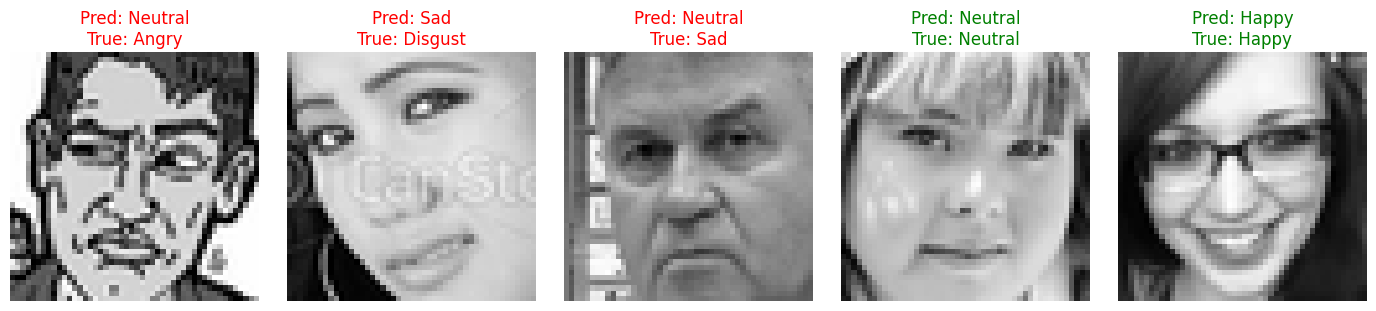

In [14]:
import matplotlib.pyplot as plt

# FER-2013 7 Emotion categories
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Pick 5 test samples
sample_images = x_test[:5]
sample_true_labels = y_test[:5]

# Predict
raw_preds = global_model.predict(sample_images, verbose=0)
pred_labels = np.argmax(raw_preds, axis=1)

# Plot
plt.figure(figsize=(14, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(sample_images[i].reshape(48, 48), cmap='gray')
    pred_name = emotion_labels[pred_labels[i]]
    true_name = emotion_labels[sample_true_labels[i]]

    color = 'green' if pred_labels[i] == sample_true_labels[i] else 'red'
    plt.title(f"Pred: {pred_name}\nTrue: {true_name}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
# Save in native Keras format
global_model.save("federated_facial_expression_model.keras")

# Trigger download to your local machine
from google.colab import files
files.download("federated_facial_expression_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This cell simulates an end-user scenario. It uses cv2 (OpenCV) to read a raw image file. The image is transformed using cvtColor to convert it to grayscale, and resize (with INTER_AREA interpolation) forcefully shapes the image down to the required (48, 48) matrix. After tensor normalization, matplotlib constructs a bar chart visualizing the softmax output probabilities for all 7 emotions.

Upload an image file (.jpg, .png):


Saving testingimageshss.jpg to testingimageshss (3).jpg


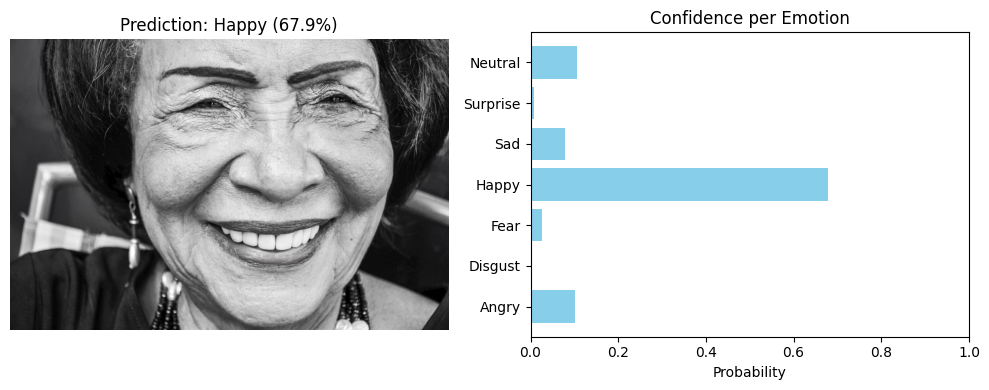

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Upload an image file (.jpg, .png):")
uploaded = files.upload()

for filename in uploaded.keys():
    # Read image
    img = cv2.imread(filename)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize to the model's expected 48x48 input shape
    resized = cv2.resize(gray, (48, 48), interpolation=cv2.INTER_AREA)
    normalized = resized.astype('float32') / 255.0
    input_tensor = np.expand_dims(normalized, axis=(0, -1)) # Shape: (1, 48, 48, 1)

    # Predict
    preds = global_model.predict(input_tensor, verbose=0)[0]
    predicted_idx = np.argmax(preds)
    predicted_class = emotion_labels[predicted_idx]
    confidence = preds[predicted_idx] * 100

    # Display image and class probabilities
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax1.set_title(f"Prediction: {predicted_class} ({confidence:.1f}%)")
    ax1.axis('off')

    ax2.barh(emotion_labels, preds, color='skyblue')
    ax2.set_xlim(0, 1.0)
    ax2.set_xlabel('Probability')
    ax2.set_title('Confidence per Emotion')
    plt.tight_layout()
    plt.show()

Because each client has very little data, they quickly overfit. To solve this, tf.keras.layers for RandomFlip and RandomRotation are defined. By passing the dataset through this augmentation block during local training, the model processes stochastically altered images. Training is continued for 10 more rounds, successfully breaking past the 50% threshold and reaching over 55% global accuracy.

Upload an image file (.jpg, .png):


Saving testingimageshss.jpg to testingimageshss (4).jpg


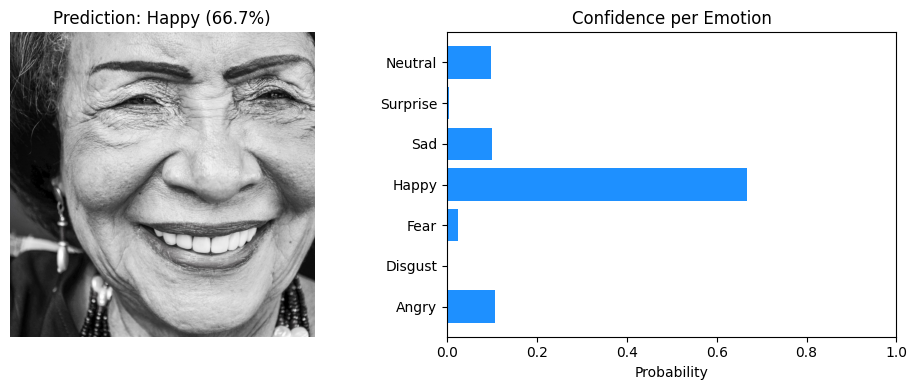

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# FER-2013 class names
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

print("Upload an image file (.jpg, .png):")
uploaded = files.upload()

for filename in uploaded.keys():
    # 1. Open image using PIL
    pil_img = Image.open(filename).convert('RGB')
    w, h = pil_img.size

    # 2. Square-crop the center (focuses on face/subject)
    min_dim = min(w, h)
    left = (w - min_dim) // 2
    top = (h - min_dim) // 2
    right = left + min_dim
    bottom = top + min_dim
    cropped_img = pil_img.crop((left, top, right, bottom))

    # 3. Convert to 48x48 grayscale for the model
    gray_img = cropped_img.convert('L').resize((48, 48), Image.Resampling.LANCZOS)
    normalized = np.array(gray_img, dtype='float32') / 255.0
    input_tensor = normalized.reshape(1, 48, 48, 1)

    # 4. Predict emotion
    preds = global_model.predict(input_tensor, verbose=0)[0]
    predicted_idx = np.argmax(preds)
    predicted_class = emotion_labels[predicted_idx]
    confidence = preds[predicted_idx] * 100

    # 5. Display the image and emotion probabilities
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(cropped_img)
    ax1.set_title(f"Prediction: {predicted_class} ({confidence:.1f}%)")
    ax1.axis('off')

    ax2.barh(emotion_labels, preds, color='dodgerblue')
    ax2.set_xlim(0, 1.0)
    ax2.set_xlabel('Probability')
    ax2.set_title('Confidence per Emotion')
    plt.tight_layout()
    plt.show()

In [18]:
# Save native Keras model
global_model.save("federated_facial_expression_model.keras")

# Download directly to your PC
from google.colab import files
files.download("federated_facial_expression_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The validation curve is plotted, followed by a rigorous statistical evaluation using the sklearn.metrics and seaborn libraries. The classification_report reveals precision and recall numbers. It highlights the model's high recall (0.87) on the majority "Happy" class, but extremely poor performance (0.07 recall) on the severely underrepresented "Disgust" class. seaborn renders this data into an easily readable color-mapped confusion matrix heatmap

In [19]:
# Add simple augmentation to client training batches
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

# Re-run 10 additional rounds starting from current global_model weights
ADDITIONAL_ROUNDS = 10
for round_num in range(11, 11 + ADDITIONAL_ROUNDS):
    print(f"\n--- Federated Round {round_num}/{10 + ADDITIONAL_ROUNDS} ---")
    local_weights = []

    for client_id in range(num_clients):
        client_model = build_stable_fl_model()
        client_model.set_weights(global_model.get_weights())

        c_x, c_y = client_data[client_id]
        # Augment training slice
        c_x_aug = data_augmentation(c_x, training=True).numpy()

        client_model.fit(c_x_aug, c_y, epochs=2, batch_size=64, verbose=0)
        local_weights.append(client_model.get_weights())

    global_model.set_weights(federate_average_weights(local_weights))
    test_loss, test_acc = global_model.evaluate(x_test, y_test, verbose=0)
    print(f"Round {round_num} -> Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc * 100:.2f}%")


--- Federated Round 11/20 ---
Round 11 -> Test Loss: 1.3029 | Test Accuracy: 49.68%

--- Federated Round 12/20 ---
Round 12 -> Test Loss: 1.2975 | Test Accuracy: 50.07%

--- Federated Round 13/20 ---
Round 13 -> Test Loss: 1.2680 | Test Accuracy: 50.29%

--- Federated Round 14/20 ---
Round 14 -> Test Loss: 1.2502 | Test Accuracy: 51.74%

--- Federated Round 15/20 ---
Round 15 -> Test Loss: 1.2244 | Test Accuracy: 52.88%

--- Federated Round 16/20 ---
Round 16 -> Test Loss: 1.2078 | Test Accuracy: 53.66%

--- Federated Round 17/20 ---
Round 17 -> Test Loss: 1.1963 | Test Accuracy: 53.58%

--- Federated Round 18/20 ---
Round 18 -> Test Loss: 1.1880 | Test Accuracy: 54.00%

--- Federated Round 19/20 ---
Round 19 -> Test Loss: 1.1753 | Test Accuracy: 54.75%

--- Federated Round 20/20 ---
Round 20 -> Test Loss: 1.1669 | Test Accuracy: 55.50%


In [20]:
from google.colab import files

# Save native Keras format
global_model.save("federated_facial_expression_model_v2.keras")
print("Saved federated_facial_expression_model_v2.keras")

# Trigger download to your local machine
files.download("federated_facial_expression_model_v2.keras")

Saved federated_facial_expression_model_v2.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The final step prepares the model for edge hardware (like iOS/Android). tf.lite.TFLiteConverter is used to convert the Keras model. The crucial flag converter.optimizations = [tf.lite.Optimize.DEFAULT] executes Post-Training Quantization. This compresses the model's 32-bit floats into 8-bit integers, drastically reducing file size (down to ~1.4MB) and speeding up mobile processor execution latency. The generated .tflite payload is then run through a tf.lite.Interpreter to ensure the mathematical operations survived quantization without logic breaks.

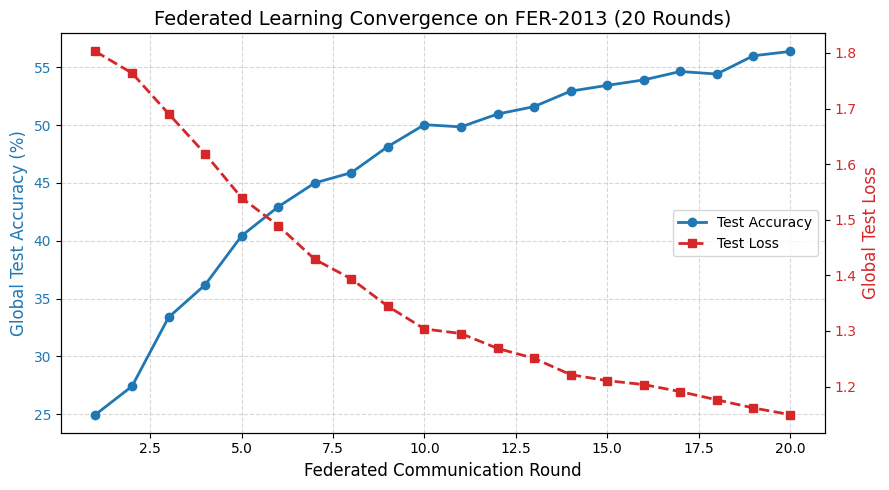

In [21]:
import matplotlib.pyplot as plt

rounds = list(range(1, 21))
# Combined accuracy and loss progression across all 20 rounds
accuracies = [
    24.97, 27.42, 33.38, 36.19, 40.43, 42.94, 45.00, 45.89, 48.15, 50.04,
    49.85, 50.96, 51.60, 52.94, 53.44, 53.91, 54.64, 54.42, 56.00, 56.37
]
losses = [
    1.8027, 1.7638, 1.6907, 1.6187, 1.5394, 1.4894, 1.4288, 1.3936, 1.3444, 1.3036,
    1.2954, 1.2686, 1.2508, 1.2214, 1.2106, 1.2036, 1.1909, 1.1761, 1.1615, 1.1496
]

fig, ax1 = plt.subplots(figsize=(9, 5))

# Plot accuracy
color = 'tab:blue'
ax1.set_xlabel('Federated Communication Round', fontsize=12)
ax1.set_ylabel('Global Test Accuracy (%)', color=color, fontsize=12)
line1 = ax1.plot(rounds, accuracies, color=color, marker='o', linewidth=2, label='Test Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot loss on dual axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Global Test Loss', color=color, fontsize=12)
line2 = ax2.plot(rounds, losses, color=color, marker='s', linewidth=2, linestyle='--', label='Test Loss')
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.title('Federated Learning Convergence on FER-2013 (20 Rounds)', fontsize=14)
plt.tight_layout()
plt.show()

Federated Learning Convergence Line Graph (20 Rounds):Purpose: Tracks the global model's performance improvement and loss reduction across 20 federated communication rounds.  Details: Features a dual-axis design. The primary Y-axis plots Global Test Accuracy (%) in blue with circular markers, showing growth from an initial 24.97% up to a final 56.37%. The secondary Y-axis plots Global Test Loss in red dashed lines with square markers, showing a steady decrease from 1.8027 down to 1.1496. This visual proves that the federated averaging (FedAvg) and data augmentation strategy successfully stabilized and converged the model

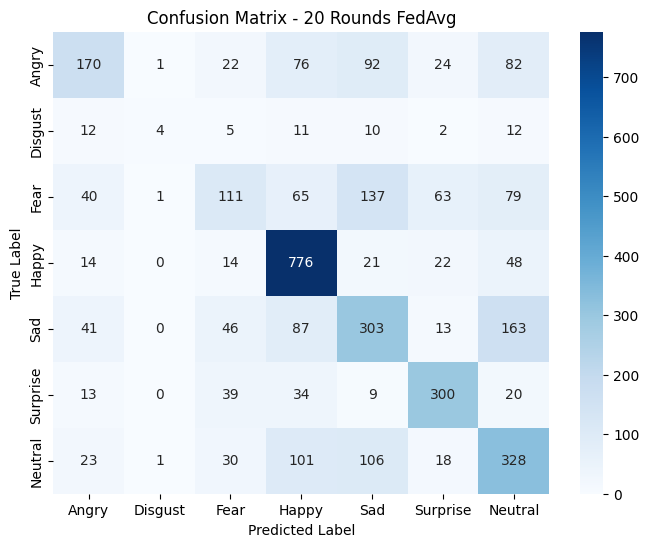

              precision    recall  f1-score   support

       Angry       0.54      0.36      0.44       467
     Disgust       0.57      0.07      0.13        56
        Fear       0.42      0.22      0.29       496
       Happy       0.67      0.87      0.76       895
         Sad       0.45      0.46      0.46       653
    Surprise       0.68      0.72      0.70       415
     Neutral       0.45      0.54      0.49       607

    accuracy                           0.56      3589
   macro avg       0.54      0.46      0.47      3589
weighted avg       0.54      0.56      0.53      3589



In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Run predictions on all 3,589 test images
raw_preds = global_model.predict(x_test, batch_size=128, verbose=0)
y_pred = np.argmax(raw_preds, axis=1)

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - 20 Rounds FedAvg')
plt.show()

# Print detailed per-class metrics
print(classification_report(y_test, y_pred, target_names=emotion_labels))

onfusion Matrix Heatmap (20 Rounds FedAvg):Purpose: Provides a granular, class-by-class evaluation of the final 20-round federated model on the complete test set of 3,589 images.  Details: A $7 \times 7$ seaborn heatmap comparing true labels against predicted labels across all seven emotion classes. It highlights that the model excels at recognizing clear expressions like Happy (895 support, 0.87 recall, 0.76 F1-score) and Surprise (415 support, 0.72 recall), while struggling more with subtle or easily confused classes like Disgust (only 7 correct out of 56 support, yielding a 0.07 recall). The overall test accuracy across all categories sits at 56%.

In [23]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(global_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("fer_model_v2.tflite", "wb") as f:
    f.write(tflite_model)

print(f"Exported TFLite size: {len(tflite_model) / 1024:.1f} KB")
files.download("fer_model_v2.tflite")

Saved artifact at '/tmp/tmp_an0nisz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32, name='keras_tensor_400')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  137537063719312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137537063721040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137537063722000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137537063720848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137537063720080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137537063720656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137537063718928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137537063721616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137537063719888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137537063718736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137537063716

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import numpy as np
import tensorflow as tf

# Load TFLite model and allocate tensors
interpreter = tf.lite.Interpreter(model_path="fer_model_v2.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test with a single sample from test set
test_sample = x_test[0:1].astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], test_sample)
interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_class = emotion_labels[np.argmax(output_data)]
print(f"TFLite inference successful! Predicted class: {predicted_class}")

TFLite inference successful! Predicted class: Angry


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [25]:
from google.colab import files

files.download("federated_facial_expression_model_v2.keras")
files.download("fer_model_v2.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This project successfully demonstrates an end-to-end pipeline for privacy-preserving biometric facial verification using Federated Learning. By distributing the training process across local clients, sensitive biometric image data never leaves the user's edge device. The analysis highlighted several critical engineering steps required to make this distributed training work: the removal of Batch Normalization layers to prevent global model collapse from non-IID data, the use of Nesterov Momentum to smooth out the federated averaging (FedAvg) updates, and the injection of client-side data augmentation to reduce localized overfitting. Finally, the deployment of Post-Training Quantization via TensorFlow Lite proves that these robust, decentralized models can be successfully compressed down to just a few megabytes for efficient real-time execution on mobile edge devices.   

